# Shuffle Dyck Counting Features for Four Models


## 0. Path Setup


In [10]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

ROOT


PosixPath('/home/hp_twist_shan/Research/Hidden State Evaluation')

## 1. Imports


In [11]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, mean_absolute_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from hse.experiments.dyck import DEFAULT_DYCK_MODEL_SPECS
from hse.models import build_model
from hse.tasks.shuffle_dyck import ShuffleDyckConfig, ShuffleDyckSampler, build_prefix_labels
from hse.utils import evaluate_causal_lm, load_yaml, train_causal_lm

sns.set_theme(style="whitegrid", context="talk")


## 2. Global Knobs


In [12]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CONFIG_PATH = ROOT / "configs" / "shuffle_dyck.yaml"
CONFIG = load_yaml(CONFIG_PATH)
TASK_NAME = CONFIG["experiment"]["name"]
MODEL_TYPES = ["rnn", "lstm", "transformer", "mamba"]
STATE_KIND_BY_MODEL = {"rnn": "h", "lstm": "c", "transformer": "h", "mamba": "h"}
COMPONENT_TARGETS = ["height_round", "height_square", "height_curly"]
RIDGE_TARGETS = COMPONENT_TARGETS + ["total_height"]
LOGISTIC_TARGETS = ["count_vector_class", "legal_next_type"]
SHORT_LABEL = {
    "height_round": "round",
    "height_square": "square",
    "height_curly": "curly",
    "total_height": "total",
}

TRAINING_STEPS = int(CONFIG["training"]["steps"])
BATCH_SIZE = int(CONFIG["training"]["batch_size"])
LEARNING_RATE = float(CONFIG["training"]["learning_rate"])
EVAL_EVERY = 200
TRAIN_SEED = 0

PREFIX_LENGTH = 8
LAYER_INDEX = -1
N_PROBE_SAMPLES = 20000
PROBE_BATCH_SIZE = 1024
BALANCE_PROBE_BY = CONFIG["analysis"]["probes"]["balance_by"]
BALANCE_SEED = 0
PROBE_MIN_CLASS_COUNT = 32
PROBE_MAX_PER_CLASS = 256
LOGISTIC_MIN_SHARED_COUNT = 8

SWEEP_PREFIX_LENGTHS = list(range(2, int(CONFIG["task"]["total_length"]), 2))
SWEEP_N_SAMPLES = 8192

FORCE_RETRAIN = False
EXPERIMENT_TAG = "formal"
RESULTS_ROOT = ROOT / "results" / "notebooks" / "shuffle_dyck_reference_style" / EXPERIMENT_TAG / TASK_NAME
RESULTS_ROOT


PosixPath('/home/hp_twist_shan/Research/Hidden State Evaluation/results/notebooks/shuffle_dyck_reference_style/formal/shuffle_dyck_no_noise')

## 3. Core Helpers


In [13]:
def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def get_task_kwargs():
    task_kwargs = dict(CONFIG["task"])
    task_kwargs["device"] = DEVICE
    return task_kwargs


def get_task_config():
    return ShuffleDyckConfig(**get_task_kwargs())


def get_model_spec(model_type):
    spec = dict(DEFAULT_DYCK_MODEL_SPECS[model_type])
    if model_type == "lstm":
        spec["state_kind"] = "c"
    return spec


def get_run_dir(model_type):
    return RESULTS_ROOT / f"{model_type}_seed{TRAIN_SEED}"


def build_fresh_model(model_type):
    spec = get_model_spec(model_type)
    model_kwargs = {k: v for k, v in spec.items() if k != "state_kind"}
    cfg = get_task_config()
    return build_model(model_name=model_type, vocab_size=cfg.vocab_size, **model_kwargs).to(DEVICE)


def make_sampler(seed_offset=0):
    return ShuffleDyckSampler(get_task_config(), seed=TRAIN_SEED + seed_offset)


def load_or_train_model(model_type):
    run_dir = get_run_dir(model_type)
    checkpoint_path = run_dir / "checkpoints" / "model_final.pt"
    metrics_path = run_dir / "metrics.json"
    config_path = run_dir / "config.json"

    model = build_fresh_model(model_type)
    train_sampler = make_sampler(seed_offset=0)

    if checkpoint_path.exists() and metrics_path.exists() and not FORCE_RETRAIN:
        payload = torch.load(checkpoint_path, map_location=DEVICE)
        model.load_state_dict(payload["model"])
        return {
            "model": model,
            "train_sampler": train_sampler,
            "metrics": load_json(metrics_path),
            "run_dir": run_dir,
            "config": load_json(config_path) if config_path.exists() else None,
        }

    run_dir.mkdir(parents=True, exist_ok=True)
    spec = get_model_spec(model_type)
    save_json(
        {
            "task_name": TASK_NAME,
            "task": get_task_kwargs(),
            "model_type": model_type,
            "model_spec": spec,
            "training_steps": TRAINING_STEPS,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "device": DEVICE,
            "seed": TRAIN_SEED,
        },
        config_path,
    )
    train_log = train_causal_lm(
        model=model,
        sampler=train_sampler,
        steps=TRAINING_STEPS,
        batch_size=BATCH_SIZE,
        lr=LEARNING_RATE,
        run_dir=run_dir,
        eval_every=EVAL_EVERY,
        device=DEVICE,
    )
    eval_metrics = evaluate_causal_lm(
        model=model,
        sampler=make_sampler(seed_offset=100),
        batch_size=BATCH_SIZE,
        device=DEVICE,
    )
    metrics = {"train": train_log, "eval": eval_metrics}
    save_json(metrics, metrics_path)
    return {
        "model": model,
        "train_sampler": train_sampler,
        "metrics": metrics,
        "run_dir": run_dir,
        "config": load_json(config_path),
    }


## 4. Training Sanity Checks


In [14]:
def moving_average_edge(x, window=11):
    x = np.asarray(x, dtype=float)
    if len(x) < window:
        return x.copy()
    left = window // 2
    right = window - 1 - left
    padded = np.pad(x, (left, right), mode="edge")
    return np.convolve(padded, np.ones(window) / window, mode="valid")


@torch.no_grad()
def compute_position_accuracy(model, sampler, *, num_samples=2048, batch_size=512):
    model.eval().to(DEVICE)
    numer = None
    denom = None
    total_correct = 0.0
    total_count = 0.0
    remaining = int(num_samples)

    while remaining > 0:
        bs = min(int(batch_size), remaining)
        batch = sampler.sample(bs)
        tokens = batch.tokens.to(DEVICE)
        dyck_mask = batch.dyck_mask.to(DEVICE)
        logits = model(tokens)
        pred = logits[:, :-1, :].argmax(dim=-1)
        target = tokens[:, 1:]
        eval_mask = dyck_mask[:, 1:]
        correct = (pred == target) & eval_mask

        batch_numer = correct.float().sum(dim=0).detach().cpu()
        batch_denom = eval_mask.float().sum(dim=0).detach().cpu()
        numer = batch_numer if numer is None else numer + batch_numer
        denom = batch_denom if denom is None else denom + batch_denom
        total_correct += float(batch_numer.sum())
        total_count += float(batch_denom.sum())
        remaining -= bs

    acc = torch.full_like(denom, float("nan"))
    valid = denom > 0
    acc[valid] = numer[valid] / denom[valid]
    return np.arange(acc.numel()), acc.numpy(), total_correct / max(total_count, 1.0)


def plot_loss_sanity(model_type, metrics):
    train_df = pd.DataFrame(metrics["train"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(train_df["step"], train_df["loss"], lw=0.8, alpha=0.55, label="raw")
    if len(train_df) >= 5:
        smooth = moving_average_edge(train_df["loss"], window=min(11, len(train_df) if len(train_df) % 2 == 1 else len(train_df) - 1))
        axes[0].plot(train_df["step"], smooth, lw=1.6, label="smoothed")
    axes[0].set_title(f"{model_type.upper()} train loss")
    axes[0].set_xlabel("step")
    axes[0].set_ylabel("cross entropy")
    axes[0].legend(frameon=False)
    axes[0].grid(True, alpha=0.25)

    axes[1].plot(train_df["step"], train_df["eval_loss"], label="eval loss", lw=1.8)
    axes[1].axhline(np.log(6), color="gray", ls="--", lw=1.0, label="log 6")
    axes[1].set_title(f"{model_type.upper()} eval loss")
    axes[1].set_xlabel("step")
    axes[1].set_ylabel("cross entropy")
    axes[1].legend(frameon=False)
    axes[1].grid(True, alpha=0.25)

    plt.tight_layout()
    plt.show()


def plot_accuracy_sanity(model_type, model):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    pos, acc, mean_acc = compute_position_accuracy(model, make_sampler(seed_offset=100))
    ax.plot(pos, acc, label=f"eval mean={mean_acc:.3f}")
    ax.set_title(f"{model_type.upper()} Shuffle-Dyck next-token accuracy")
    ax.set_xlabel("target position")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0, 1.02)
    ax.legend(frameon=False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()
    print(f"{model_type.upper()} mean accuracy: eval={mean_acc:.4f}")
    return {"eval": mean_acc}


In [15]:
loaded_models = {}
sanity_results = {}


## 4A. Train RNN


SANITY: rnn


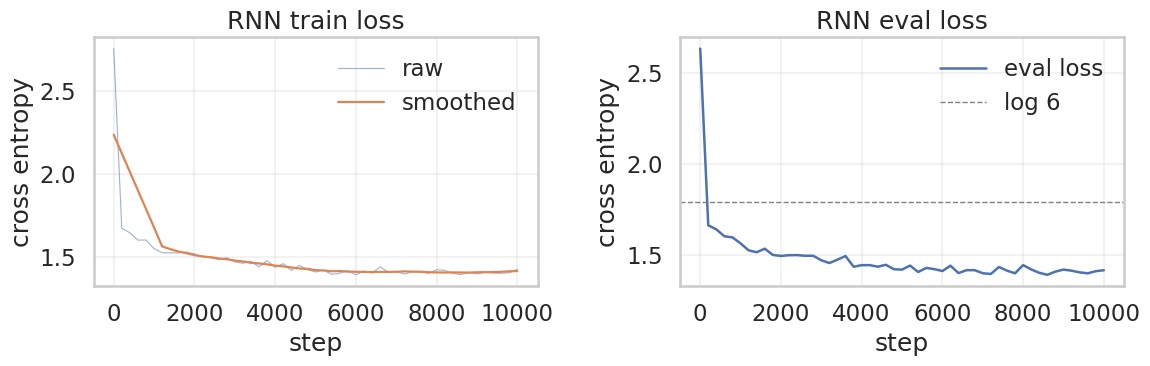

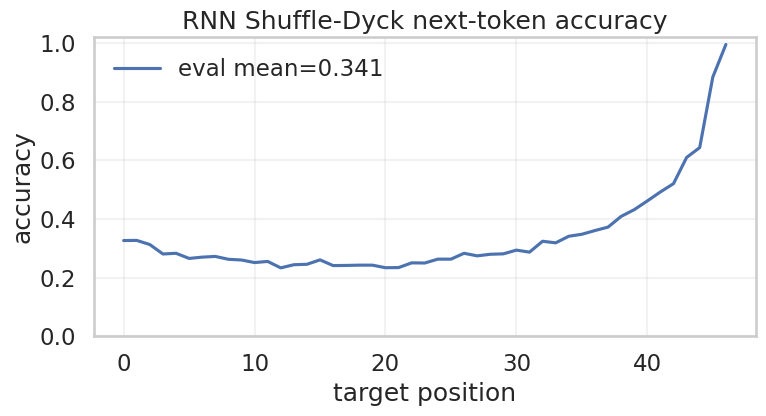

RNN mean accuracy: eval=0.3407


In [16]:
model_type = "rnn"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])


## 4B. Train LSTM


SANITY: lstm


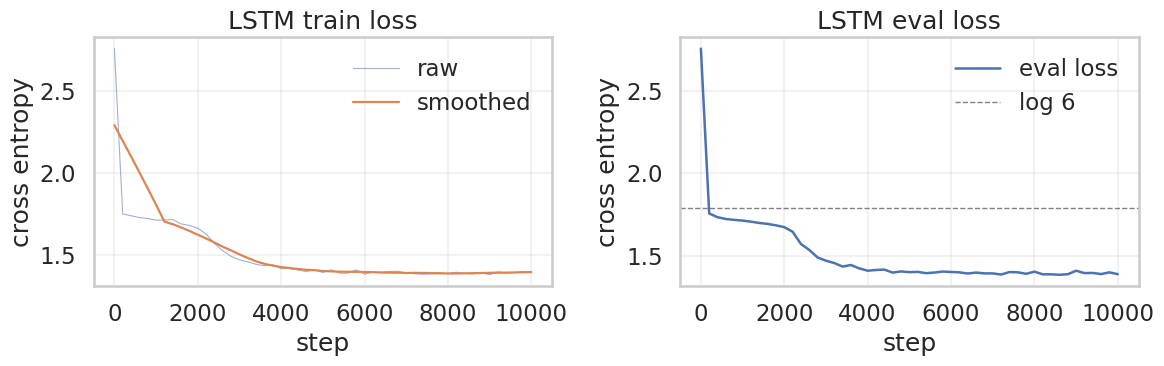

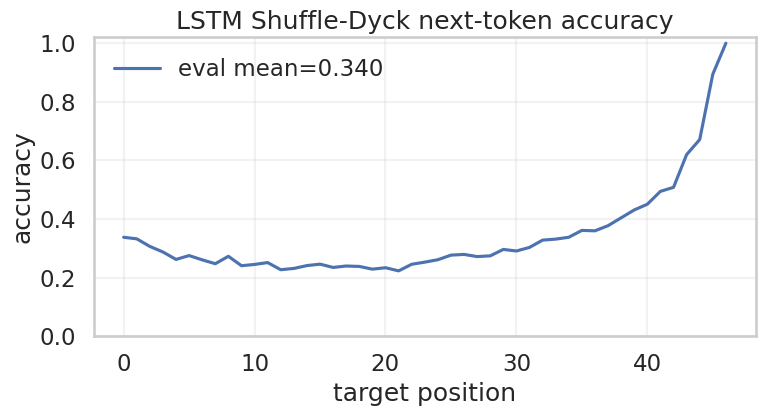

LSTM mean accuracy: eval=0.3397


In [17]:
model_type = "lstm"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])


## 4C. Train Transformer


SANITY: transformer


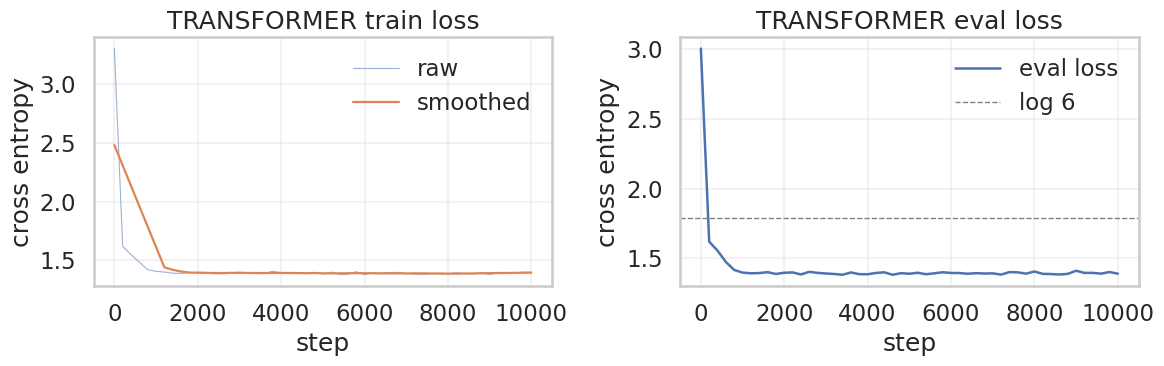

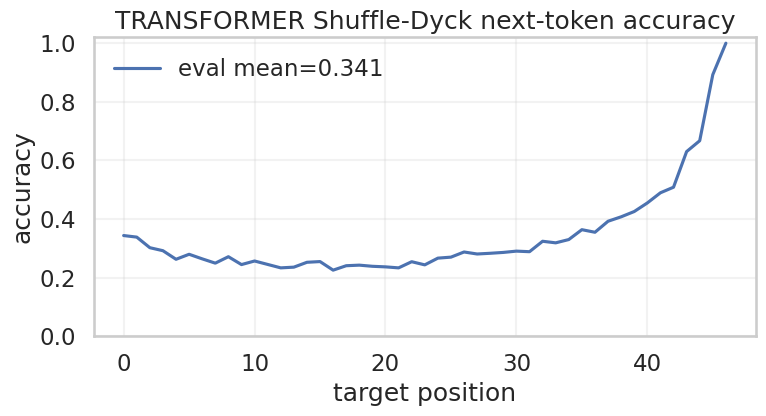

TRANSFORMER mean accuracy: eval=0.3412


In [18]:
model_type = "transformer"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])


## 4D. Train Mamba


SANITY: mamba


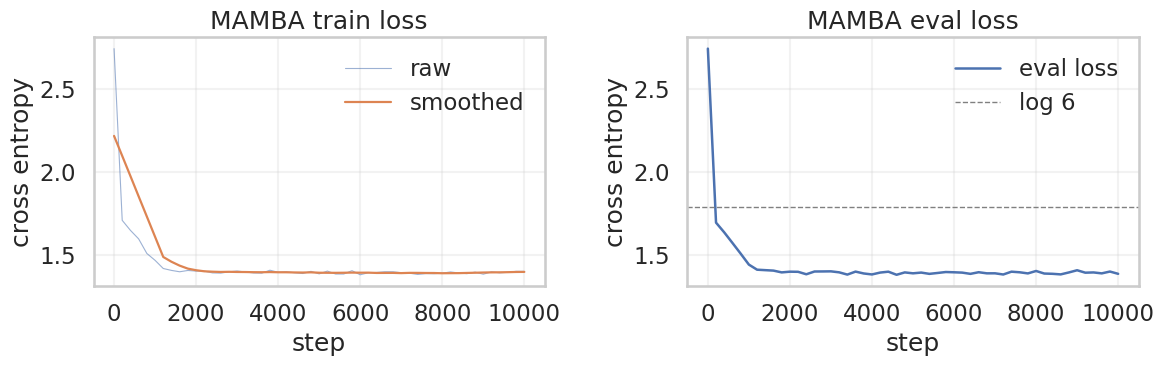

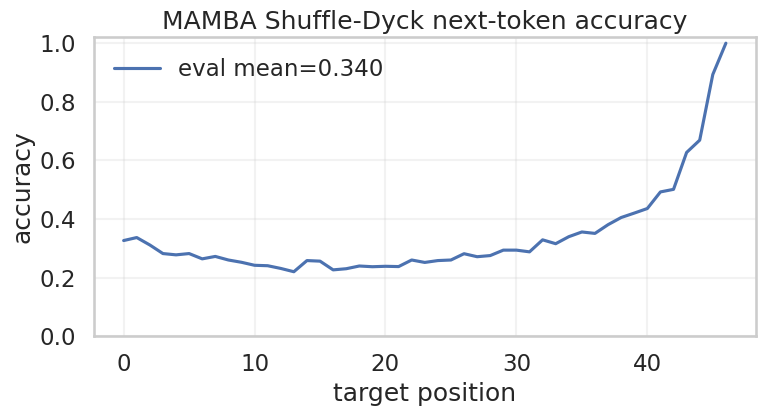

MAMBA mean accuracy: eval=0.3395


In [19]:
model_type = "mamba"
print("=" * 80)
print(f"SANITY: {model_type}")
payload = load_or_train_model(model_type)
loaded_models[model_type] = payload
plot_loss_sanity(model_type, payload["metrics"])
sanity_results[model_type] = plot_accuracy_sanity(model_type, payload["model"])


## 5. Counter Probe Data and Probe Fitting


从固定 prefix 长度处抽 hidden state，配上 `height_round / height_square / height_curly / total_height / count_vector_class / legal_next_type` 标签，做类别平衡、拟合 ridge/logistic probe，并把 learned direction 提取出来。

In [20]:
@torch.no_grad()
def sample_hidden_count_matrix(
    model,
    sampler,
    *,
    prefix_length=PREFIX_LENGTH,
    layer_index=LAYER_INDEX,
    state_kind="h",
    n_samples=N_PROBE_SAMPLES,
    batch_size=PROBE_BATCH_SIZE,
):
    cfg = sampler.config
    assert 1 <= prefix_length <= cfg.total_length
    assert cfg.generation_prob >= 1.0, "This notebook assumes Shuffle Dyck no-noise prefixes."
    model.eval().to(DEVICE)

    hs = []
    prefixes = []
    component_heights = {target: [] for target in COMPONENT_TARGETS}
    total_heights = []
    count_vectors = []
    legal_next_types = []
    next_tokens = []
    remaining = int(n_samples)

    while remaining > 0:
        bs = min(int(batch_size), remaining)
        batch = sampler.sample(bs)
        tokens = batch.tokens.to(DEVICE)
        states = model.extract_states(tokens, layer_index=layer_index, state_kind=state_kind)
        hs.append(states[:, prefix_length - 1, :].detach().cpu().numpy())
        prefixes.append(tokens[:, :prefix_length].detach().cpu().numpy())

        labels = build_prefix_labels(batch, config=cfg, max_prefix_len=None)
        labels = labels.loc[labels["position"] == prefix_length - 1].reset_index(drop=True)
        for target in COMPONENT_TARGETS:
            component_heights[target].append(labels[target].to_numpy())
        total_heights.append(labels["total_height"].to_numpy())
        count_vectors.append(labels["count_vector_class"].to_numpy())
        legal_next_types.append(labels["legal_next_type"].to_numpy())
        if prefix_length < cfg.seq_len:
            next_tokens.append(tokens[:, prefix_length].detach().cpu().numpy())
        remaining -= bs

    data = {
        "h": np.concatenate(hs, axis=0),
        "prefix": np.concatenate(prefixes, axis=0),
        "total_height": np.concatenate(total_heights, axis=0),
        "count_vector_class": np.concatenate(count_vectors, axis=0),
        "legal_next_type": np.concatenate(legal_next_types, axis=0),
    }
    for target in COMPONENT_TARGETS:
        data[target] = np.concatenate(component_heights[target], axis=0)
    data["height_vector"] = np.stack([data[target] for target in COMPONENT_TARGETS], axis=1)
    if next_tokens:
        data["next_token"] = np.concatenate(next_tokens, axis=0)
    return data


def balance_data_by_label(data, label="count_vector_class", seed=0, max_per_class=PROBE_MAX_PER_CLASS, min_per_class=PROBE_MIN_CLASS_COUNT):
    if label is None or label not in data:
        return data
    y = np.asarray(data[label])
    classes, counts = np.unique(y, return_counts=True)
    keep_classes = classes[counts >= min_per_class]
    if len(keep_classes) <= 1:
        return data

    keep_mask = np.isin(y, keep_classes)
    filtered = {k: np.asarray(v)[keep_mask] for k, v in data.items()}
    y = np.asarray(filtered[label])
    classes, counts = np.unique(y, return_counts=True)
    target = int(counts.min()) if max_per_class is None else min(int(counts.min()), int(max_per_class))

    rng = np.random.default_rng(seed)
    idx_parts = []
    for cls in classes:
        cls_idx = np.flatnonzero(y == cls)
        idx_parts.append(rng.choice(cls_idx, size=target, replace=False))
    idx = np.concatenate(idx_parts)
    rng.shuffle(idx)
    return {k: np.asarray(v)[idx] for k, v in filtered.items()}


def print_class_balance(data, label="count_vector_class", name="data", limit=12):
    classes, counts = np.unique(np.asarray(data[label]), return_counts=True)
    order = np.argsort(counts)[::-1]
    parts = [f"{int(classes[i])}:{int(counts[i])}" for i in order[:limit]]
    suffix = " ..." if len(order) > limit else ""
    print(f"{name} {label} counts -> " + ", ".join(parts) + suffix)


def fit_ridge_probe(X_train, y_train, X_test, y_test, name):
    probe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    probe.fit(X_train, y_train)
    pred = probe.predict(X_test)
    return {
        "name": name,
        "probe": probe,
        "r2": float(r2_score(y_test, pred)),
        "mae": float(mean_absolute_error(y_test, pred)),
    }


def fit_vector_ridge_probe(X_train, y_train, X_test, y_test, name):
    probe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
    probe.fit(X_train, y_train)
    pred = probe.predict(X_test)
    return {
        "name": name,
        "probe": probe,
        "r2_mean": float(r2_score(y_test, pred, multioutput="uniform_average")),
        "r2_var_weighted": float(r2_score(y_test, pred, multioutput="variance_weighted")),
        "mae": float(mean_absolute_error(y_test, pred)),
        "per_dim_r2": r2_score(y_test, pred, multioutput="raw_values"),
    }


def restrict_to_shared_classes(X_train, y_train, X_test, y_test, min_count=LOGISTIC_MIN_SHARED_COUNT):
    train_counts = pd.Series(y_train).value_counts()
    test_counts = pd.Series(y_test).value_counts()
    keep = np.intersect1d(
        train_counts[train_counts >= min_count].index.to_numpy(),
        test_counts[test_counts >= min_count].index.to_numpy(),
    )
    train_mask = np.isin(y_train, keep)
    test_mask = np.isin(y_test, keep)
    return X_train[train_mask], y_train[train_mask], X_test[test_mask], y_test[test_mask]


def fit_logistic_probe(X_train, y_train, X_test, y_test, name):
    X_train_use, y_train_use, X_test_use, y_test_use = restrict_to_shared_classes(X_train, y_train, X_test, y_test)
    train_classes = np.unique(y_train_use)
    test_classes = np.unique(y_test_use)
    if len(train_classes) < 2 or len(test_classes) < 2:
        return {"name": name, "probe": None, "accuracy": float("nan"), "n_classes": int(len(train_classes))}
    probe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, C=1.0, solver="lbfgs"))
    probe.fit(X_train_use, y_train_use)
    pred = probe.predict(X_test_use)
    return {
        "name": name,
        "probe": probe,
        "accuracy": float(accuracy_score(y_test_use, pred)),
        "n_classes": int(len(train_classes)),
    }


def run_counting_probes(train_data, test_data):
    X_train = train_data["h"]
    X_test = test_data["h"]
    rows = []
    fitted = {}

    for target in RIDGE_TARGETS:
        out = fit_ridge_probe(X_train, train_data[target], X_test, test_data[target], target)
        fitted[f"ridge_{target}"] = out["probe"]
        rows.append({"probe": "ridge", "target": target, "metric": "r2", "value": out["r2"]})
        rows.append({"probe": "ridge", "target": target, "metric": "mae", "value": out["mae"]})

    vector_out = fit_vector_ridge_probe(X_train, train_data["height_vector"], X_test, test_data["height_vector"], "height_vector")
    fitted["ridge_height_vector"] = vector_out["probe"]
    rows.append({"probe": "ridge", "target": "height_vector", "metric": "r2_mean", "value": vector_out["r2_mean"]})
    rows.append({"probe": "ridge", "target": "height_vector", "metric": "r2_var_weighted", "value": vector_out["r2_var_weighted"]})
    rows.append({"probe": "ridge", "target": "height_vector", "metric": "mae", "value": vector_out["mae"]})

    for target, value in zip(COMPONENT_TARGETS, vector_out["per_dim_r2"]):
        rows.append({"probe": "ridge", "target": f"{target}_joint", "metric": "r2", "value": float(value)})

    for target in LOGISTIC_TARGETS:
        out = fit_logistic_probe(X_train, train_data[target], X_test, test_data[target], target)
        fitted[f"logistic_{target}"] = out["probe"]
        rows.append({"probe": "logistic", "target": target, "metric": "accuracy", "value": out["accuracy"]})
        rows.append({"probe": "logistic", "target": target, "metric": "n_classes", "value": out["n_classes"]})

    return rows, fitted


def _normalize(v):
    return v / (np.linalg.norm(v) + 1e-12)


def _ridge_direction(ridge_pipeline):
    scaler = ridge_pipeline.named_steps["standardscaler"]
    ridge = ridge_pipeline.named_steps["ridge"]
    return ridge.coef_ / scaler.scale_


def _project_on_ridge_direction(X, ridge_pipeline, center=True, standardize=True):
    direction = _normalize(_ridge_direction(ridge_pipeline))
    X_use = X - X.mean(axis=0, keepdims=True) if center else X
    z = X_use @ direction
    if standardize:
        z = (z - z.mean()) / (z.std() + 1e-12)
    return z


def summarize_counting_directions(fitted):
    direction_targets = COMPONENT_TARGETS + ["total_height"]
    directions = {target: _normalize(_ridge_direction(fitted[f"ridge_{target}"])) for target in direction_targets}
    print("direction cosine summary")
    for a, b in [("height_round", "height_square"), ("height_round", "height_curly"), ("height_square", "height_curly")]:
        print(f"  cos({SHORT_LABEL[a]}, {SHORT_LABEL[b]}) = {np.dot(directions[a], directions[b]):+.4f}")
    sum_direction = _normalize(sum(directions[target] for target in COMPONENT_TARGETS))
    print(f"  cos(total, normalized sum) = {np.dot(directions['total_height'], sum_direction):+.4f}")


## 6. PCA Views by Per-Type Height


1. 用 PCA 粗看 hidden state 的全局结构
2. 直接沿 learned counter directions 做投影，看三种计数器是不是形成了清晰的离散格子
3. 用 cosine heatmap 总结几种 counter direction 的相对关系。


In [21]:
def plot_height_pca_panels(data, *, title, max_points=5000):
    X = np.asarray(data["h"])
    idx = np.arange(len(X))
    if len(idx) > max_points:
        rng = np.random.default_rng(0)
        idx = rng.choice(idx, size=max_points, replace=False)
    X = X[idx]
    X2 = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    plot_targets = COMPONENT_TARGETS + ["total_height"]
    cmaps = ["coolwarm", "coolwarm", "coolwarm", "viridis"]
    for ax, target, cmap in zip(axes.ravel(), plot_targets, cmaps):
        sc = ax.scatter(X2[:, 0], X2[:, 1], c=np.asarray(data[target])[idx], s=12, alpha=0.65, cmap=cmap, linewidths=0)
        ax.set_title(f"{title} | color={SHORT_LABEL.get(target, target)}")
        ax.set_xlabel("PC1")
        ax.set_ylabel("PC2")
        ax.grid(True, alpha=0.25)
        fig.colorbar(sc, ax=ax, shrink=0.82)
    plt.tight_layout()
    plt.show()


def plot_counter_subspace_pairs(data, fitted, *, title, max_points=5000):
    X = np.asarray(data["h"])
    idx = np.arange(len(X))
    if len(idx) > max_points:
        rng = np.random.default_rng(1)
        idx = rng.choice(idx, size=max_points, replace=False)

    projections = {target: _project_on_ridge_direction(X, fitted[f"ridge_{target}"])[idx] for target in COMPONENT_TARGETS + ["total_height"]}
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    pair_specs = [
        ("height_round", "height_square", "height_curly"),
        ("height_round", "height_curly", "height_square"),
        ("height_square", "height_curly", "height_round"),
    ]

    for ax, (x_name, y_name, c_name) in zip(axes.ravel()[:3], pair_specs):
        sc = ax.scatter(
            projections[x_name],
            projections[y_name],
            c=np.asarray(data[c_name])[idx],
            s=12,
            alpha=0.65,
            cmap="coolwarm",
            linewidths=0,
        )
        ax.set_xlabel(f"proj {SHORT_LABEL[x_name]}")
        ax.set_ylabel(f"proj {SHORT_LABEL[y_name]}")
        ax.set_title(f"color={SHORT_LABEL[c_name]}")
        ax.grid(True, alpha=0.25)
        fig.colorbar(sc, ax=ax, shrink=0.82)

    ax = axes.ravel()[3]
    ax.scatter(np.asarray(data["total_height"])[idx], projections["total_height"], s=12, alpha=0.55, linewidths=0)
    ax.set_xlabel("true total height")
    ax.set_ylabel("projection on total-height direction")
    ax.set_title(f"{title} | total-height readout")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()


def plot_direction_cosine_heatmap(fitted, *, title):
    direction_targets = COMPONENT_TARGETS + ["total_height"]
    directions = {target: _normalize(_ridge_direction(fitted[f"ridge_{target}"])) for target in direction_targets}
    mat = np.zeros((len(direction_targets), len(direction_targets)))
    for i, a in enumerate(direction_targets):
        for j, b in enumerate(direction_targets):
            mat[i, j] = float(np.dot(directions[a], directions[b]))
    labels = [SHORT_LABEL[target] for target in direction_targets]
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


## 7. Counter Subspace Plots


MODEL: rnn
rnn train raw count_vector_class counts -> 172:1604, 90:1562, 92:1535, 10:1527, 100:1507, 82:1479, 2:559, 164:552, 18:544, 180:536, 162:526, 20:511 ...
rnn test raw count_vector_class counts -> 10:1543, 172:1530, 92:1527, 90:1524, 82:1489, 100:1476, 162:568, 20:559, 164:544, 180:533, 182:520, 2:516 ...
rnn train balanced count_vector_class counts -> 414:32, 352:32, 344:32, 342:32, 334:32, 326:32, 324:32, 272:32, 270:32, 264:32, 262:32, 254:32 ...
rnn test balanced count_vector_class counts -> 344:39, 342:39, 334:39, 326:39, 324:39, 272:39, 270:39, 264:39, 262:39, 254:39, 252:39, 246:39 ...
   ridge       height_round           r2: 0.9458
   ridge       height_round          mae: 0.2314
   ridge      height_square           r2: 0.8954
   ridge      height_square          mae: 0.3117
   ridge       height_curly           r2: 0.9633
   ridge       height_curly          mae: 0.1661
   ridge       total_height           r2: 0.9241
   ridge       total_height          mae: 0.3893


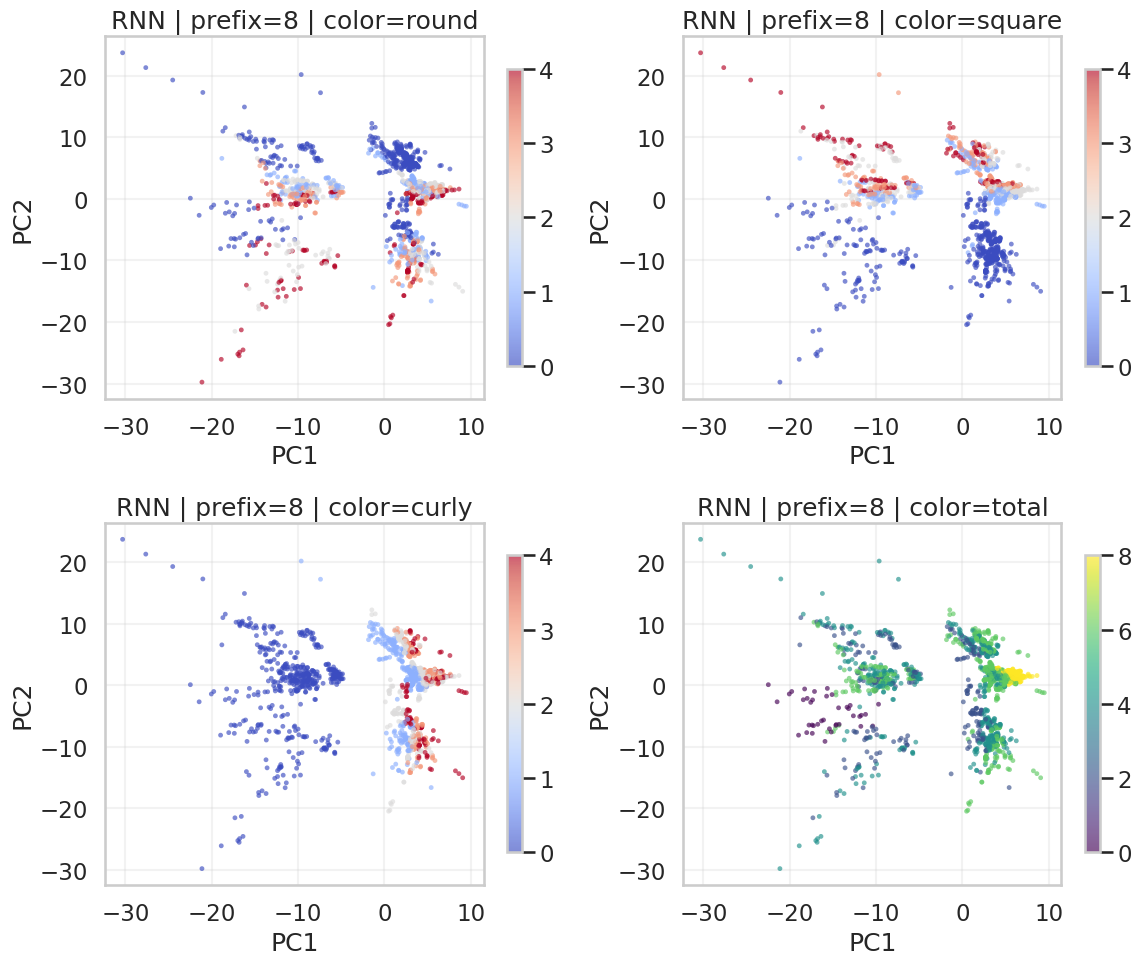

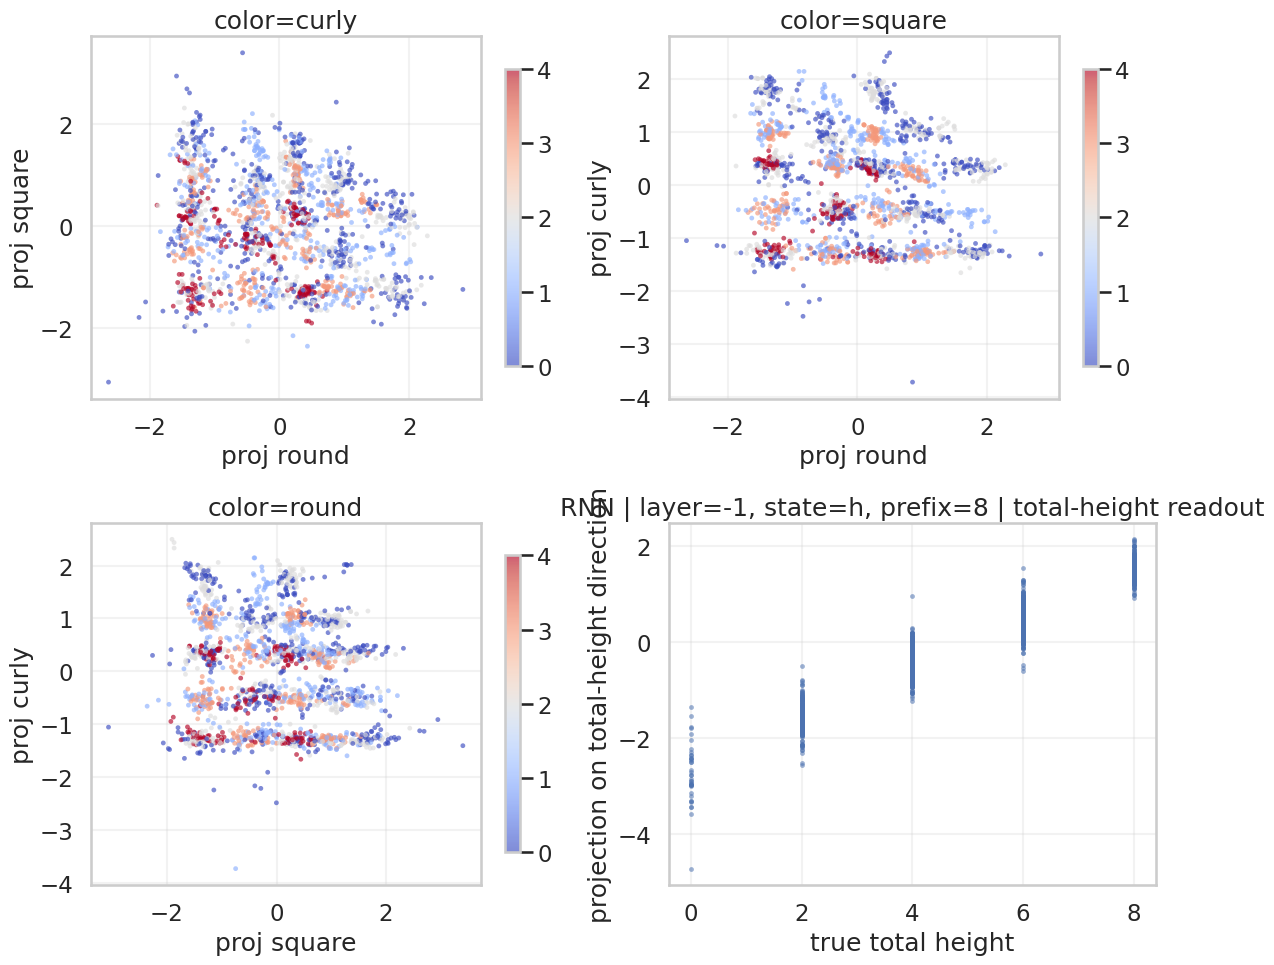

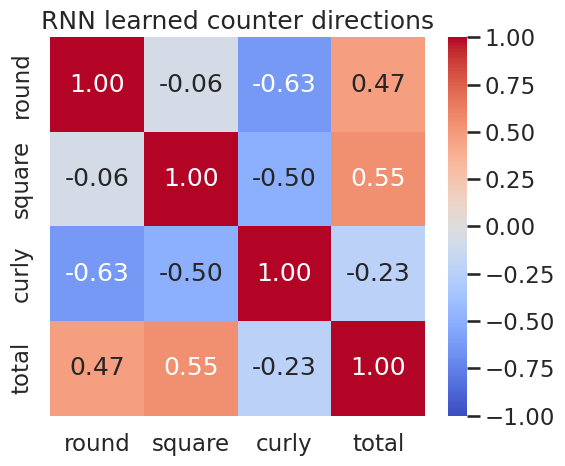

MODEL: lstm
lstm train raw count_vector_class counts -> 172:1604, 90:1562, 92:1535, 10:1527, 100:1507, 82:1479, 2:559, 164:552, 18:544, 180:536, 162:526, 20:511 ...
lstm test raw count_vector_class counts -> 10:1543, 172:1530, 92:1527, 90:1524, 82:1489, 100:1476, 162:568, 20:559, 164:544, 180:533, 182:520, 2:516 ...
lstm train balanced count_vector_class counts -> 414:32, 352:32, 344:32, 342:32, 334:32, 326:32, 324:32, 272:32, 270:32, 264:32, 262:32, 254:32 ...
lstm test balanced count_vector_class counts -> 344:39, 342:39, 334:39, 326:39, 324:39, 272:39, 270:39, 264:39, 262:39, 254:39, 252:39, 246:39 ...
   ridge       height_round           r2: 0.9852
   ridge       height_round          mae: 0.1214
   ridge      height_square           r2: 0.9884
   ridge      height_square          mae: 0.1094
   ridge       height_curly           r2: 0.9752
   ridge       height_curly          mae: 0.1567
   ridge       total_height           r2: 0.9949
   ridge       total_height          mae: 0.

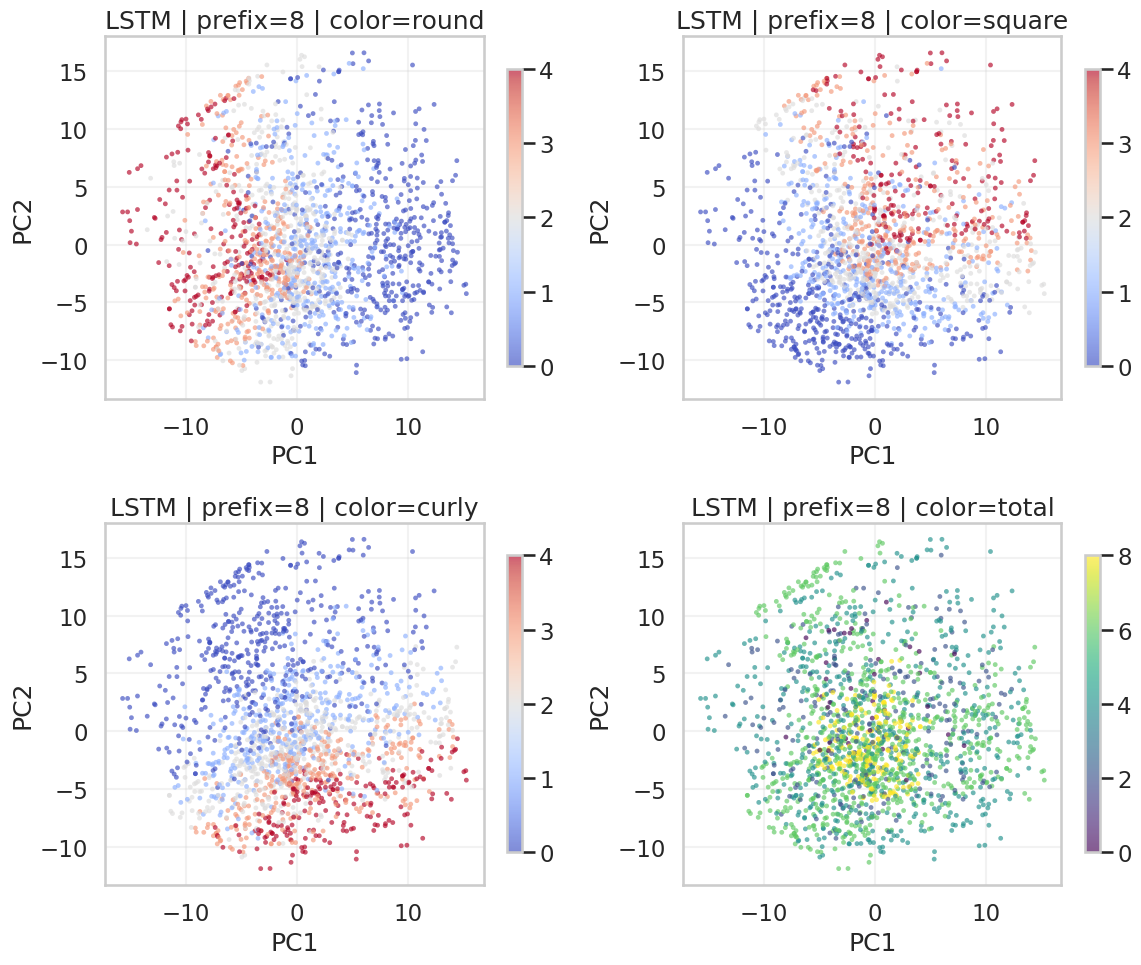

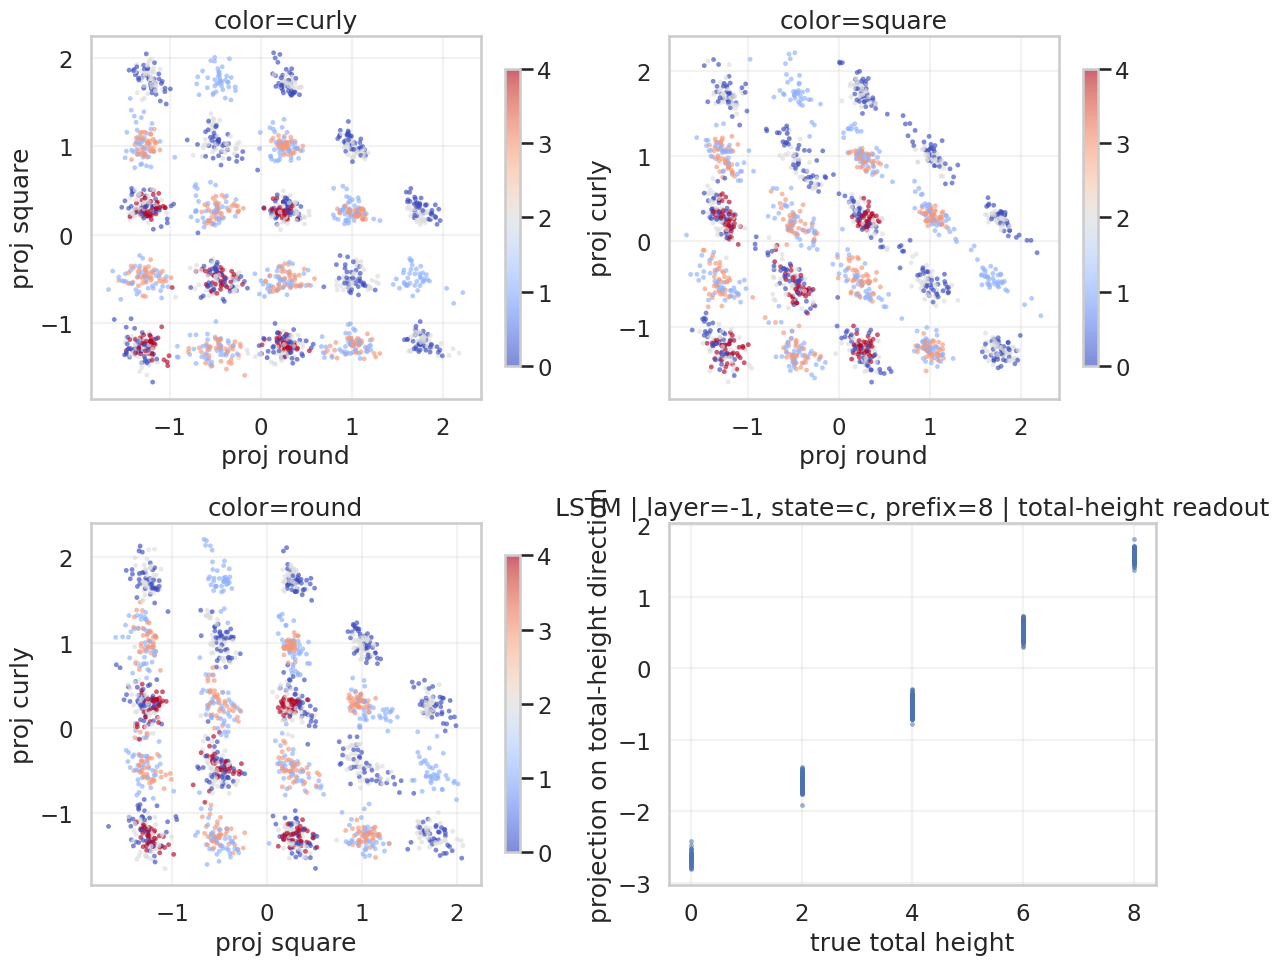

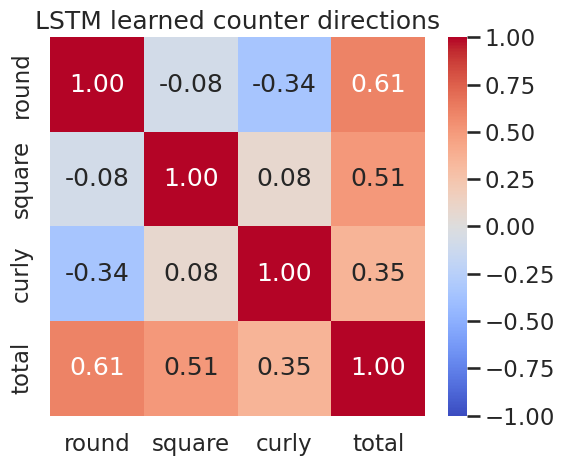

MODEL: transformer
transformer train raw count_vector_class counts -> 172:1604, 90:1562, 92:1535, 10:1527, 100:1507, 82:1479, 2:559, 164:552, 18:544, 180:536, 162:526, 20:511 ...
transformer test raw count_vector_class counts -> 10:1543, 172:1530, 92:1527, 90:1524, 82:1489, 100:1476, 162:568, 20:559, 164:544, 180:533, 182:520, 2:516 ...
transformer train balanced count_vector_class counts -> 414:32, 352:32, 344:32, 342:32, 334:32, 326:32, 324:32, 272:32, 270:32, 264:32, 262:32, 254:32 ...
transformer test balanced count_vector_class counts -> 344:39, 342:39, 334:39, 326:39, 324:39, 272:39, 270:39, 264:39, 262:39, 254:39, 252:39, 246:39 ...
   ridge       height_round           r2: 0.9988
   ridge       height_round          mae: 0.0354
   ridge      height_square           r2: 0.9989
   ridge      height_square          mae: 0.0352
   ridge       height_curly           r2: 0.9992
   ridge       height_curly          mae: 0.0306
   ridge       total_height           r2: 0.9987
   ridge 

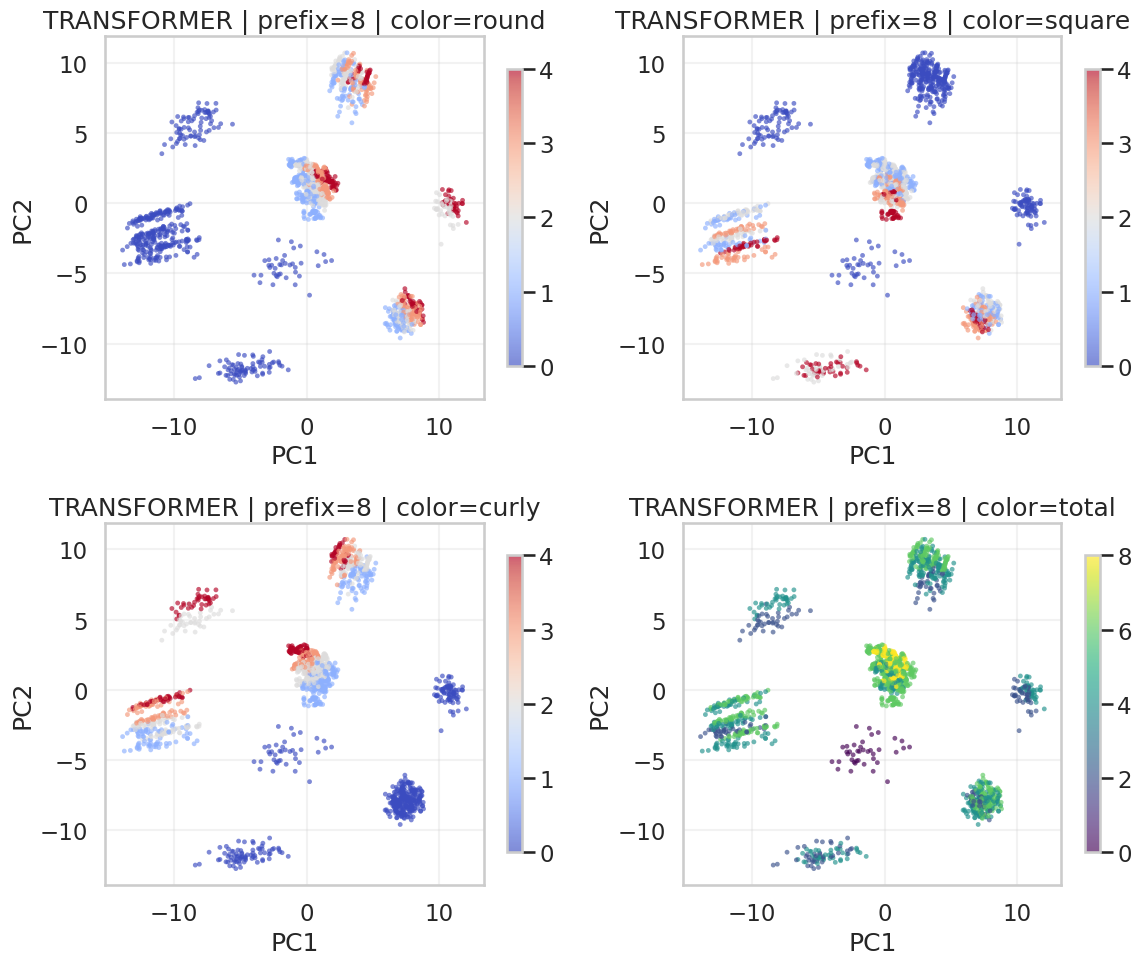

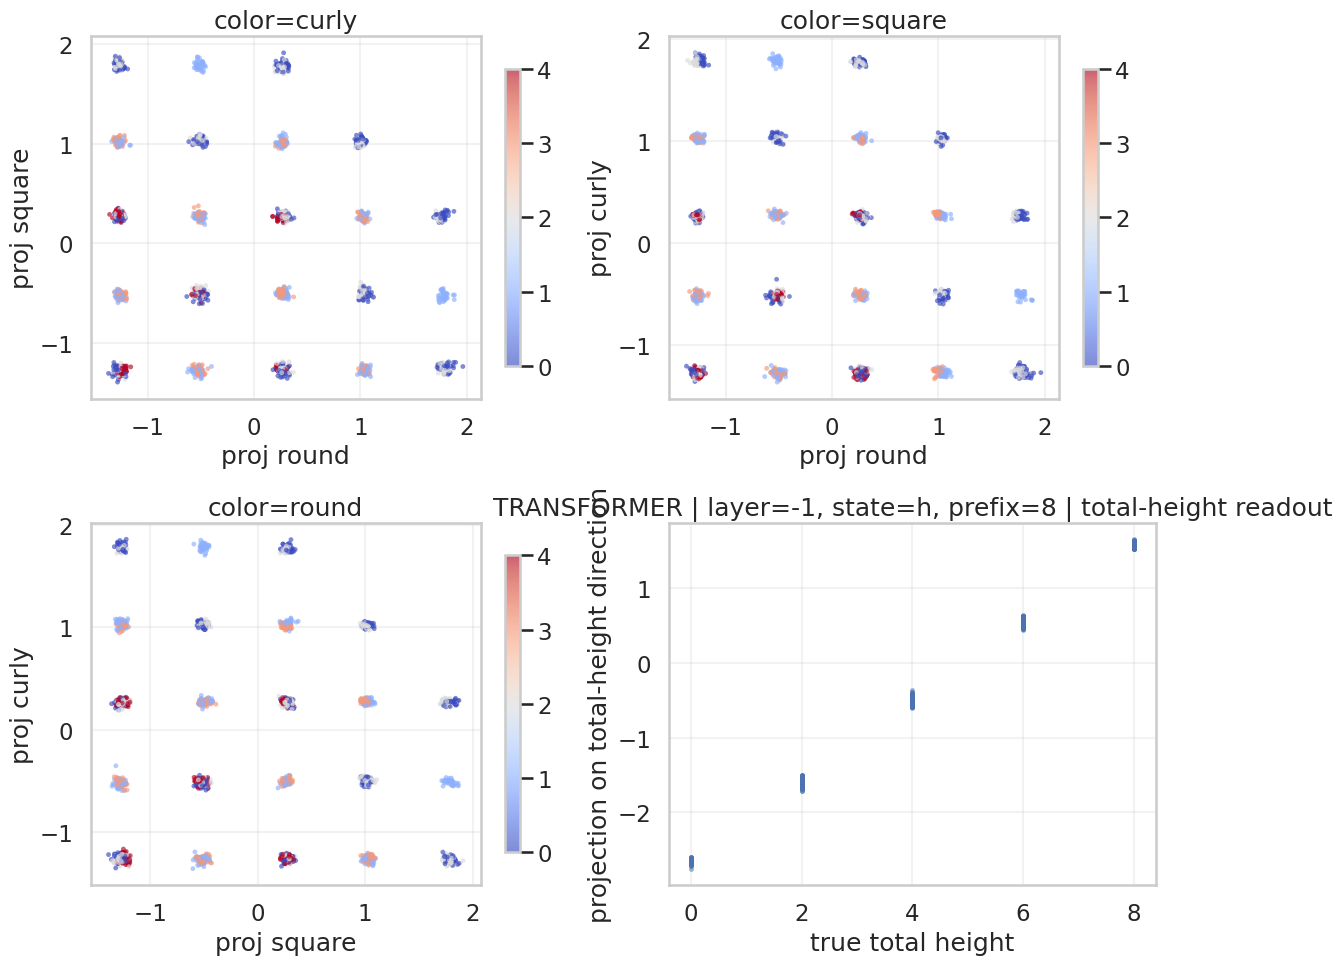

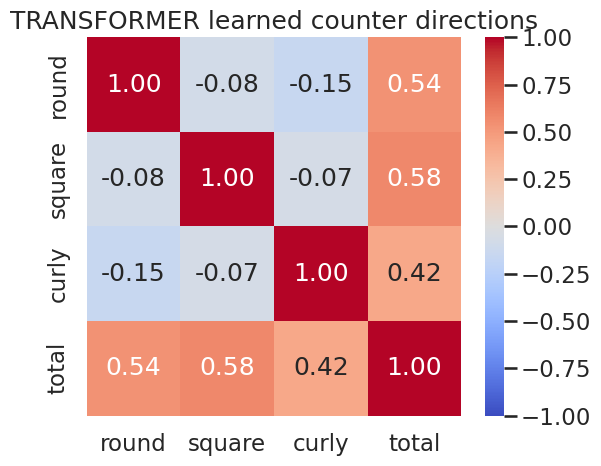

MODEL: mamba
mamba train raw count_vector_class counts -> 172:1604, 90:1562, 92:1535, 10:1527, 100:1507, 82:1479, 2:559, 164:552, 18:544, 180:536, 162:526, 20:511 ...
mamba test raw count_vector_class counts -> 10:1543, 172:1530, 92:1527, 90:1524, 82:1489, 100:1476, 162:568, 20:559, 164:544, 180:533, 182:520, 2:516 ...
mamba train balanced count_vector_class counts -> 414:32, 352:32, 344:32, 342:32, 334:32, 326:32, 324:32, 272:32, 270:32, 264:32, 262:32, 254:32 ...
mamba test balanced count_vector_class counts -> 344:39, 342:39, 334:39, 326:39, 324:39, 272:39, 270:39, 264:39, 262:39, 254:39, 252:39, 246:39 ...
   ridge       height_round           r2: 0.8941
   ridge       height_round          mae: 0.3383
   ridge      height_square           r2: 0.8688
   ridge      height_square          mae: 0.3789
   ridge       height_curly           r2: 0.9528
   ridge       height_curly          mae: 0.2216
   ridge       total_height           r2: 0.9050
   ridge       total_height          ma

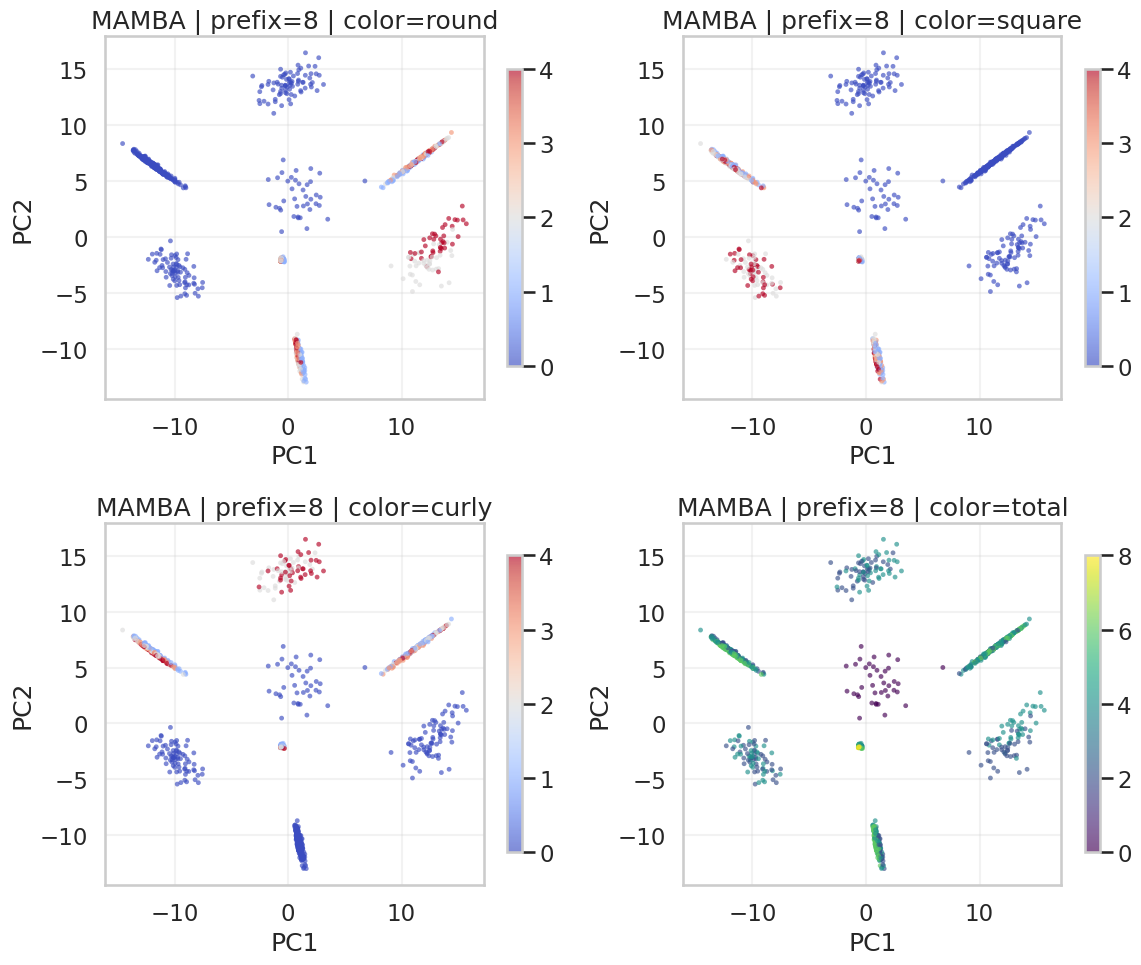

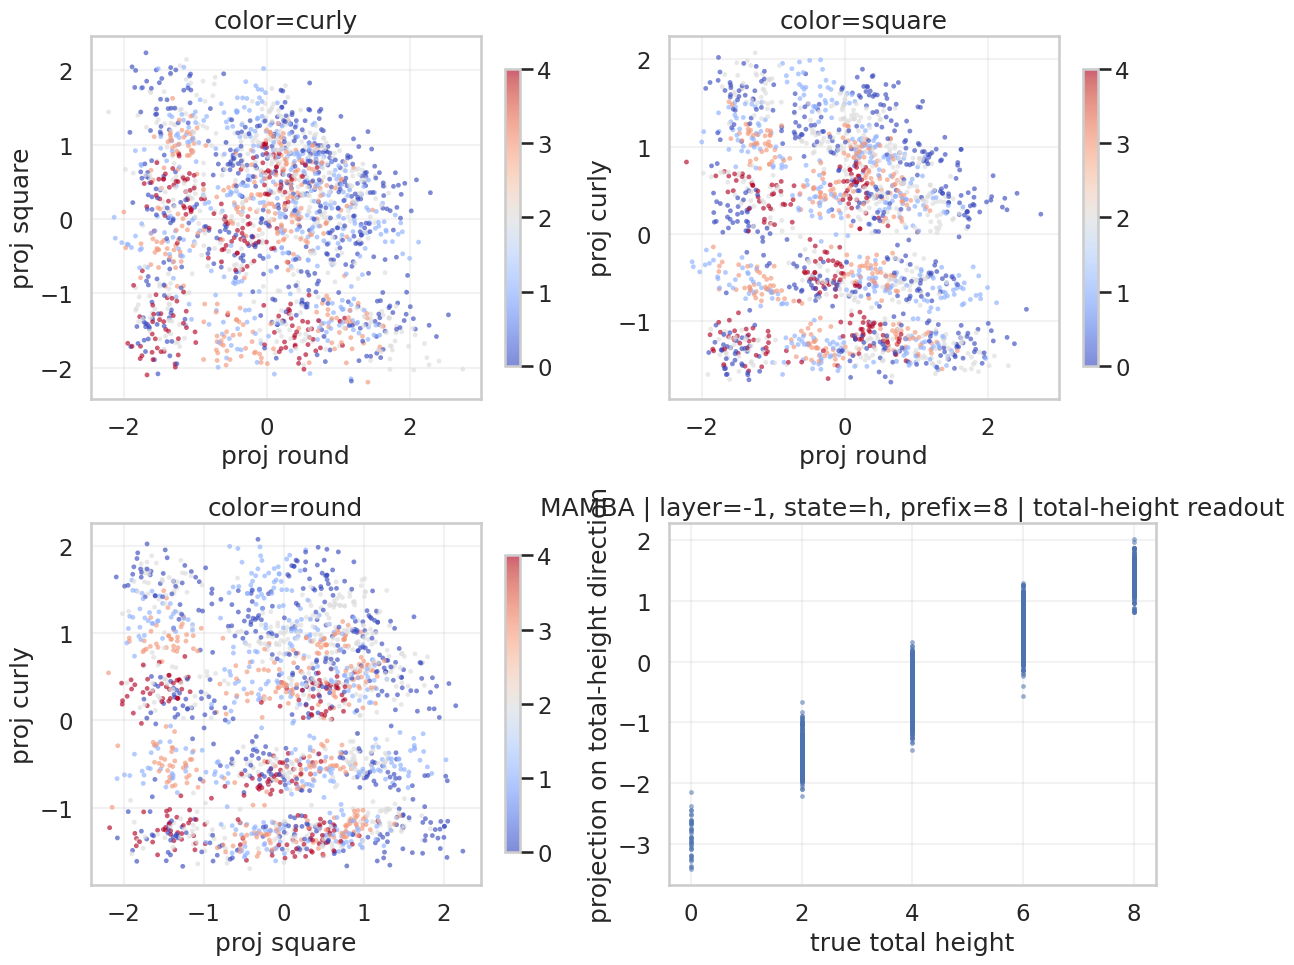

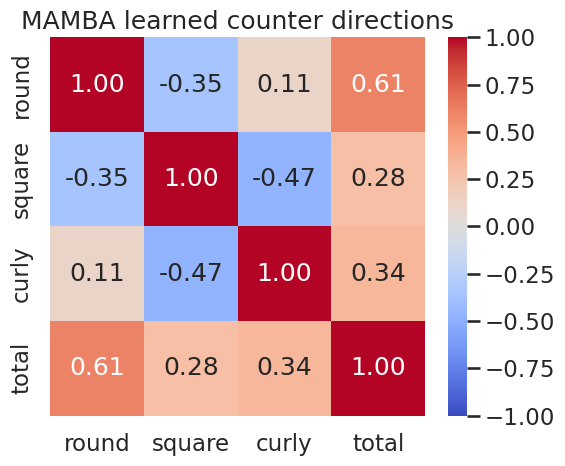

In [22]:
all_results = {}

for model_type in MODEL_TYPES:
    print("=" * 80)
    print(f"MODEL: {model_type}")
    payload = loaded_models[model_type]
    model = payload["model"]
    state_kind = STATE_KIND_BY_MODEL[model_type]

    train_data = sample_hidden_count_matrix(
        model,
        make_sampler(seed_offset=300),
        prefix_length=PREFIX_LENGTH,
        layer_index=LAYER_INDEX,
        state_kind=state_kind,
        n_samples=N_PROBE_SAMPLES,
    )
    test_data = sample_hidden_count_matrix(
        model,
        make_sampler(seed_offset=400),
        prefix_length=PREFIX_LENGTH,
        layer_index=LAYER_INDEX,
        state_kind=state_kind,
        n_samples=N_PROBE_SAMPLES,
    )

    print_class_balance(train_data, BALANCE_PROBE_BY, name=f"{model_type} train raw")
    print_class_balance(test_data, BALANCE_PROBE_BY, name=f"{model_type} test raw")
    train_probe_data = balance_data_by_label(train_data, BALANCE_PROBE_BY, seed=BALANCE_SEED)
    test_probe_data = balance_data_by_label(test_data, BALANCE_PROBE_BY, seed=BALANCE_SEED + 1)
    print_class_balance(train_probe_data, BALANCE_PROBE_BY, name=f"{model_type} train balanced")
    print_class_balance(test_probe_data, BALANCE_PROBE_BY, name=f"{model_type} test balanced")

    rows, fitted = run_counting_probes(train_probe_data, test_probe_data)
    all_results[model_type] = {
        "rows": rows,
        "fitted": fitted,
        "train_data": train_data,
        "test_data": test_data,
        "train_probe_data": train_probe_data,
        "test_probe_data": test_probe_data,
    }

    for row in rows:
        print(f"{row['probe']:>8s} {row['target']:>18s} {row['metric']:>12s}: {row['value']:.4f}")

    summarize_counting_directions(fitted)
    plot_height_pca_panels(
        test_probe_data,
        title=f"{model_type.upper()} | prefix={PREFIX_LENGTH}",
    )
    plot_counter_subspace_pairs(
        test_probe_data,
        fitted,
        title=f"{model_type.upper()} | layer={LAYER_INDEX}, state={state_kind}, prefix={PREFIX_LENGTH}",
    )
    plot_direction_cosine_heatmap(
        fitted,
        title=f"{model_type.upper()} learned counter directions",
    )


## 8. Prefix Sweep


PREFIX SWEEP: rnn
rnn prefix=2
rnn prefix=4
rnn prefix=6
rnn prefix=8
rnn prefix=10
rnn prefix=12
rnn prefix=14
rnn prefix=16
rnn prefix=18
rnn prefix=20
rnn prefix=22
rnn prefix=24
rnn prefix=26
rnn prefix=28
rnn prefix=30
rnn prefix=32
rnn prefix=34
rnn prefix=36
rnn prefix=38
rnn prefix=40
rnn prefix=42
rnn prefix=44
rnn prefix=46
PREFIX SWEEP: lstm
lstm prefix=2
lstm prefix=4
lstm prefix=6
lstm prefix=8
lstm prefix=10
lstm prefix=12
lstm prefix=14
lstm prefix=16
lstm prefix=18
lstm prefix=20
lstm prefix=22
lstm prefix=24
lstm prefix=26
lstm prefix=28
lstm prefix=30
lstm prefix=32
lstm prefix=34
lstm prefix=36
lstm prefix=38
lstm prefix=40
lstm prefix=42
lstm prefix=44
lstm prefix=46
PREFIX SWEEP: transformer
transformer prefix=2
transformer prefix=4
transformer prefix=6
transformer prefix=8
transformer prefix=10
transformer prefix=12
transformer prefix=14
transformer prefix=16
transformer prefix=18
transformer prefix=20
transformer prefix=22
transformer prefix=24
transformer prefix

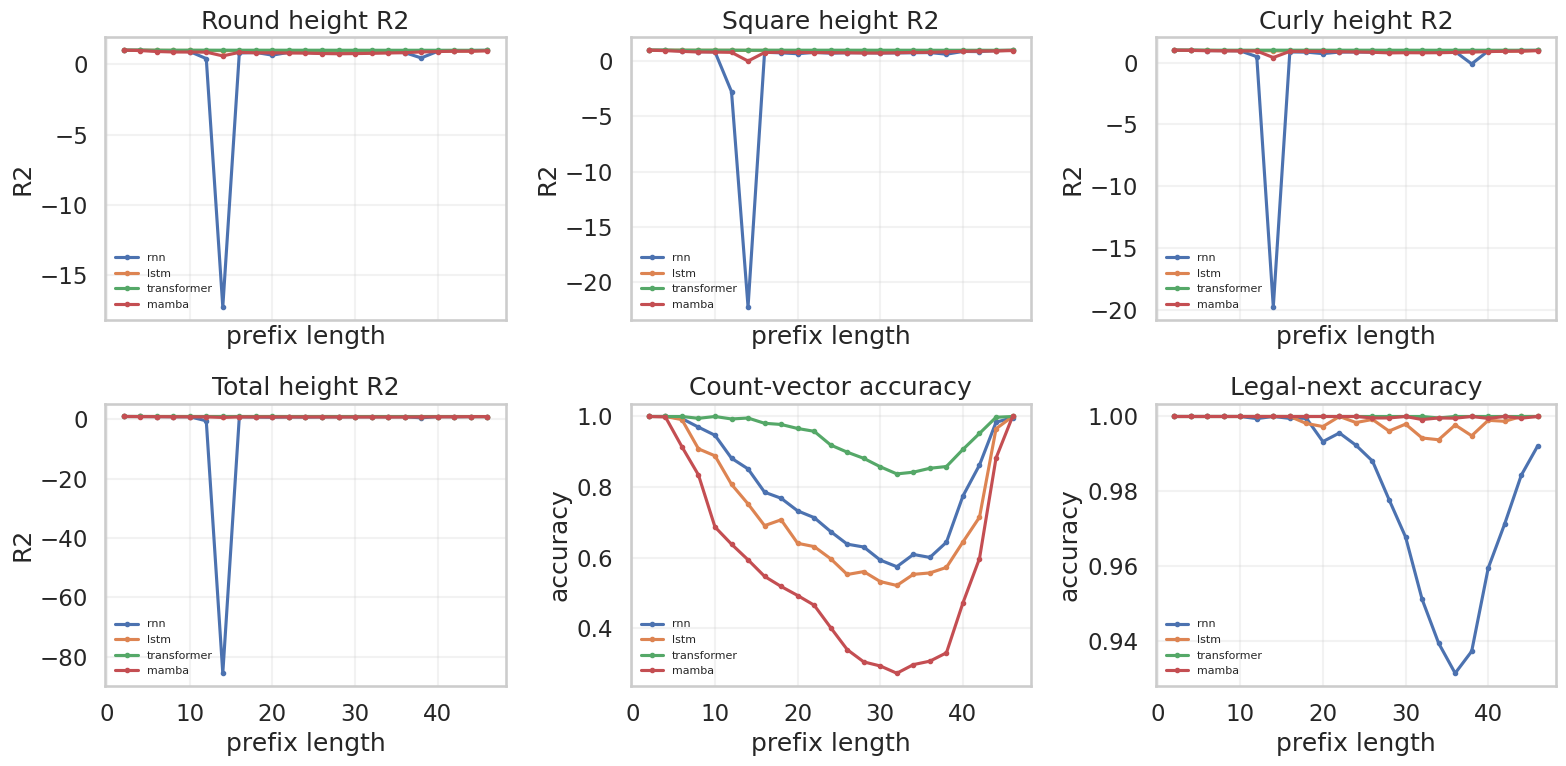

In [23]:
def _rows_to_lookup(rows):
    lookup = {}
    for row in rows:
        lookup[(row["probe"], row["target"], row["metric"])] = row["value"]
    return lookup


def run_prefix_sweep_for_model(model_type):
    model = loaded_models[model_type]["model"]
    state_kind = STATE_KIND_BY_MODEL[model_type]
    sweep_rows = []
    directions = {}

    for prefix_length in SWEEP_PREFIX_LENGTHS:
        print(f"{model_type} prefix={prefix_length}")
        train_data = sample_hidden_count_matrix(
            model,
            make_sampler(seed_offset=600 + prefix_length),
            prefix_length=prefix_length,
            layer_index=LAYER_INDEX,
            state_kind=state_kind,
            n_samples=SWEEP_N_SAMPLES,
        )
        test_data = sample_hidden_count_matrix(
            model,
            make_sampler(seed_offset=700 + prefix_length),
            prefix_length=prefix_length,
            layer_index=LAYER_INDEX,
            state_kind=state_kind,
            n_samples=SWEEP_N_SAMPLES,
        )
        train_data = balance_data_by_label(train_data, BALANCE_PROBE_BY, seed=BALANCE_SEED)
        test_data = balance_data_by_label(test_data, BALANCE_PROBE_BY, seed=BALANCE_SEED + 1)

        rows, fitted = run_counting_probes(train_data, test_data)
        lookup = _rows_to_lookup(rows)
        row = {
            "model": model_type,
            "prefix": prefix_length,
            "round_r2": lookup[("ridge", "height_round", "r2")],
            "square_r2": lookup[("ridge", "height_square", "r2")],
            "curly_r2": lookup[("ridge", "height_curly", "r2")],
            "total_r2": lookup[("ridge", "total_height", "r2")],
            "vector_r2": lookup[("ridge", "height_vector", "r2_mean")],
            "count_vector_acc": lookup[("logistic", "count_vector_class", "accuracy")],
            "legal_next_acc": lookup[("logistic", "legal_next_type", "accuracy")],
        }
        sweep_rows.append(row)

        directions[prefix_length] = {
            target: _normalize(_ridge_direction(fitted[f"ridge_{target}"]))
            for target in COMPONENT_TARGETS + ["total_height"]
        }
    return sweep_rows, directions


prefix_sweep_results = {}
for model_type in MODEL_TYPES:
    print("=" * 80)
    print(f"PREFIX SWEEP: {model_type}")
    rows, directions = run_prefix_sweep_for_model(model_type)
    prefix_sweep_results[model_type] = {"rows": rows, "directions": directions}


def plot_prefix_sweep(prefix_sweep_results):
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
    metric_specs = [
        ("round_r2", "Round height R2", "R2"),
        ("square_r2", "Square height R2", "R2"),
        ("curly_r2", "Curly height R2", "R2"),
        ("total_r2", "Total height R2", "R2"),
        ("count_vector_acc", "Count-vector accuracy", "accuracy"),
        ("legal_next_acc", "Legal-next accuracy", "accuracy"),
    ]
    for ax, (key, title, ylabel) in zip(axes.ravel(), metric_specs):
        for model_type, result in prefix_sweep_results.items():
            rows = result["rows"]
            prefixes = np.asarray([r["prefix"] for r in rows])
            vals = np.asarray([r[key] for r in rows])
            ax.plot(prefixes, vals, marker="o", ms=3, label=model_type)
        ax.set_title(title)
        ax.set_xlabel("prefix length")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


plot_prefix_sweep(prefix_sweep_results)


## 9. Direction Arithmetic


检验：三种括号的 counter direction 是否接近正交，以及 `total height` 是否接近 `round + square + curly` 的和。


RNN
prefix | cos(r,s) | cos(r,c) | cos(s,c) | cos(total,sum)
     2 | +0.712 | +0.710 | +0.901 | +0.994
     4 | +0.026 | +0.288 | +0.073 | +0.987
     6 | -0.140 | -0.255 | +0.226 | +0.990
     8 | -0.594 | -0.708 | +0.533 | +0.910
    10 | +0.685 | -0.839 | -0.602 | +0.936
    12 | -0.549 | +0.469 | -0.794 | +0.781
    14 | -0.495 | -0.607 | +0.542 | +0.892
    16 | +0.108 | -0.395 | -0.666 | +0.750
    18 | +0.633 | -0.801 | -0.769 | +0.906
    20 | +0.512 | -0.765 | -0.794 | +0.891
    22 | +0.420 | -0.538 | -0.945 | +0.669
    24 | +0.644 | -0.594 | -0.344 | +0.935
    26 | -0.264 | -0.344 | -0.595 | +0.454
    28 | +0.202 | -0.628 | -0.842 | +0.776
    30 | -0.916 | -0.660 | +0.430 | +0.796
    32 | -0.675 | -0.536 | -0.098 | +0.816
    34 | -0.707 | -0.682 | +0.201 | +0.843
    36 | -0.297 | -0.731 | -0.044 | +0.278
    38 | -0.062 | -0.886 | -0.379 | +0.649
    40 | -0.600 | -0.580 | +0.145 | +0.511
    42 | -0.247 | -0.210 | -0.476 | +0.998
    44 | -0.114 | -0.610 | -0.453 | 

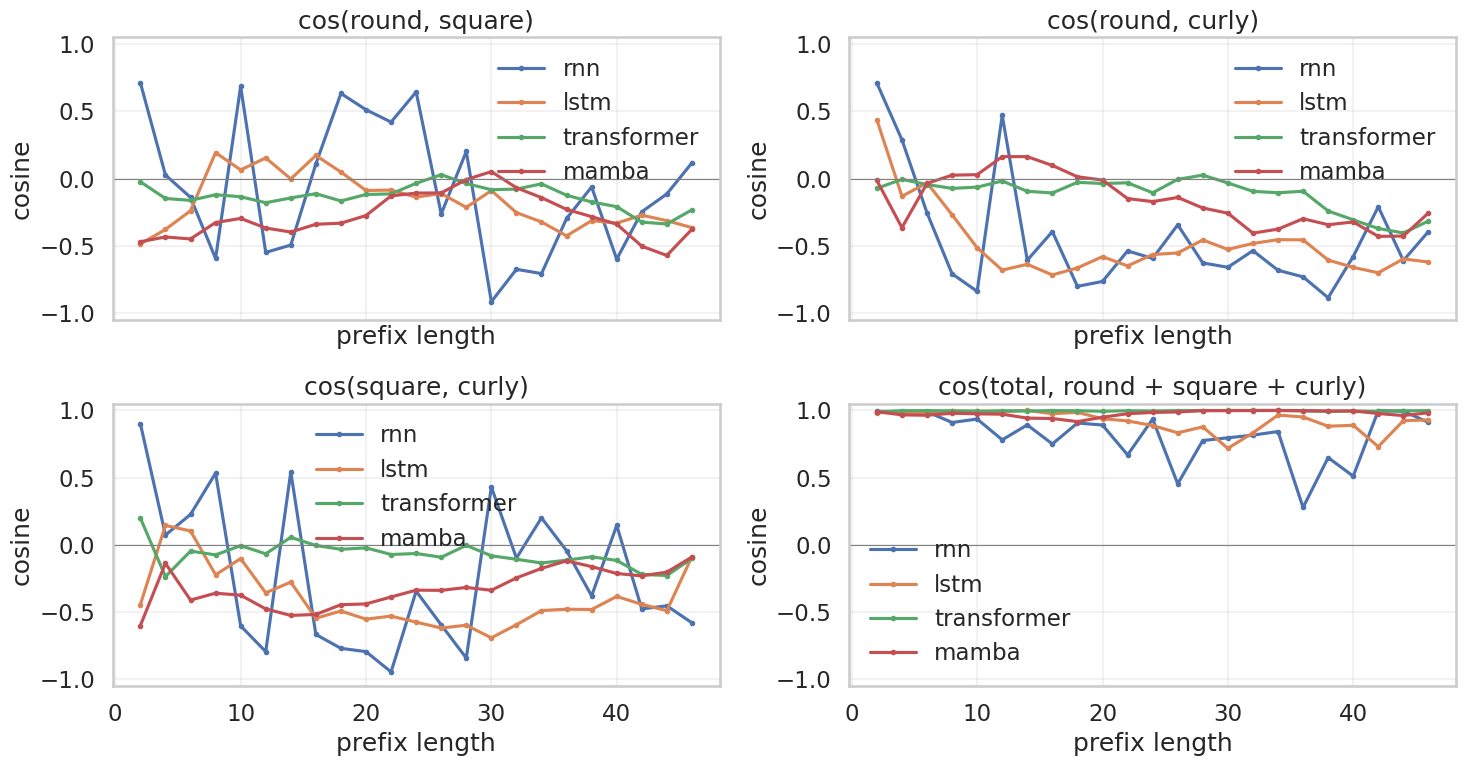

In [24]:
def direction_arithmetic_table(prefix_sweep_results):
    rows = []
    for model_type, result in prefix_sweep_results.items():
        directions = result["directions"]
        for prefix, d in directions.items():
            w_round = d["height_round"]
            w_square = d["height_square"]
            w_curly = d["height_curly"]
            w_total = d["total_height"]
            w_sum = _normalize(w_round + w_square + w_curly)
            rows.append({
                "model": model_type,
                "prefix": prefix,
                "cos_round_square": float(np.dot(w_round, w_square)),
                "cos_round_curly": float(np.dot(w_round, w_curly)),
                "cos_square_curly": float(np.dot(w_square, w_curly)),
                "cos_total_sum": float(np.dot(w_total, w_sum)),
            })
    return rows


direction_arithmetic_rows = direction_arithmetic_table(prefix_sweep_results)

for model_type in MODEL_TYPES:
    print("=" * 80)
    print(model_type.upper())
    rows = [r for r in direction_arithmetic_rows if r["model"] == model_type]
    print("prefix | cos(r,s) | cos(r,c) | cos(s,c) | cos(total,sum)")
    for r in rows:
        print(
            f"{r['prefix']:>6d} | {r['cos_round_square']:+.3f} | {r['cos_round_curly']:+.3f} | {r['cos_square_curly']:+.3f} | {r['cos_total_sum']:+.3f}"
        )


def plot_direction_arithmetic(direction_arithmetic_rows):
    fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
    metrics = [
        ("cos_round_square", "cos(round, square)"),
        ("cos_round_curly", "cos(round, curly)"),
        ("cos_square_curly", "cos(square, curly)"),
        ("cos_total_sum", "cos(total, round + square + curly)"),
    ]
    for ax, (key, title) in zip(axes.ravel(), metrics):
        for model_type in MODEL_TYPES:
            rows = [r for r in direction_arithmetic_rows if r["model"] == model_type]
            prefixes = [r["prefix"] for r in rows]
            vals = [r[key] for r in rows]
            ax.plot(prefixes, vals, marker="o", ms=3, label=model_type)
        ax.axhline(0, color="gray", lw=0.8)
        ax.set_title(title)
        ax.set_xlabel("prefix length")
        ax.set_ylabel("cosine")
        ax.set_ylim(-1.05, 1.05)
        ax.grid(True, alpha=0.25)
        ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


plot_direction_arithmetic(direction_arithmetic_rows)
